<a href="https://colab.research.google.com/github/Shashin-Pavaskar/Data-science-and-Machine-learning-/blob/main/physics_rag.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Physics Literature RAG — Question Answering over Scientific Papers

A retrieval-augmented generation (RAG) pipeline built over a corpus of physics research papers.
Built from first principles using sentence-transformers, FAISS, and Phi-3.5-mini-instruct —
no high-level chain abstractions, so every step is transparent and inspectable.

## Pipeline
1. Fetch PDFs directly from arXiv
2. Extract and clean text with PyMuPDF
3. Chunk documents across three strategies and compare retrieval quality
4. Embed with `sentence-transformers/all-MiniLM-L6-v2`
5. Index with FAISS for fast approximate nearest-neighbour retrieval
6. Generate grounded answers with `microsoft/Phi-3.5-mini-instruct` (4-bit quantised)
7. Evaluate chunking strategies on retrieval latency, source diversity, and answer quality

In [1]:
!pip install -q pymupdf sentence-transformers faiss-cpu \
    transformers bitsandbytes accelerate langchain-text-splitters

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 25.0/25.0 MB 35.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 51.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 10.3 MB/s eta 0:00:00


## 1. Download Papers from arXiv

In [2]:
import os, requests, time
from pathlib import Path

PAPERS = [
    ("2511.07514", "Quantum Calculations of the Cavity Shift in Electron g-2 Measurements"),
    ("2411.11971", "Hunting Axion Dark Matter with Anti-Ferromagnets: A Case Study with NiO"),
    ("2411.09761", "An EFT for Anisotropic Anti-Ferromagnets: Gapped Goldstones and Phase Transitions"),
    ("2409.18379", "First Principle Predictions for Cold Fermionic Gases near Criticality"),
    ("2212.10587", "Dispersion Relations for Dislocation Modes and Sensitivity to Lattice Structure"),
    ("2210.13516", "Optimal Anti-Ferromagnets for Light Dark Matter Detection"),
    ("2112.13873", "An Effective Field Theory of Magneto-Elasticity"),
    ("2103.09339", "First Principles Prediction of the Landau Parameter for Fermi Liquids"),
]

pdf_dir = Path("papers")
pdf_dir.mkdir(exist_ok=True)

for arxiv_id, title in PAPERS:
    path = pdf_dir / f"{arxiv_id}.pdf"
    if path.exists():
        print(f"  [cached] {arxiv_id}")
        continue
    r = requests.get(f"https://arxiv.org/pdf/{arxiv_id}", timeout=30)
    r.raise_for_status()
    path.write_bytes(r.content)
    print(f"  [downloaded] {arxiv_id} — {title[:55]}")
    time.sleep(1)

print(f"\nTotal papers: {len(list(pdf_dir.glob('*.pdf')))}")

  [downloaded] 2511.07514 — Quantum Calculations of the Cavity Shift in Electron g-
  [downloaded] 2411.11971 — Hunting Axion Dark Matter with Anti-Ferromagnets: A Cas
  [downloaded] 2411.09761 — An EFT for Anisotropic Anti-Ferromagnets: Gapped Goldst
  [downloaded] 2409.18379 — First Principle Predictions for Cold Fermionic Gases ne
  [downloaded] 2212.10587 — Dispersion Relations for Dislocation Modes and Sensitiv
  [downloaded] 2210.13516 — Optimal Anti-Ferromagnets for Light Dark Matter Detecti
  [downloaded] 2112.13873 — An Effective Field Theory of Magneto-Elasticity
  [downloaded] 2103.09339 — First Principles Prediction of the Landau Parameter for

Total papers: 8


## 2. Extract and Clean Text

In [3]:
import fitz, re

def extract_text(pdf_path):
    doc = fitz.open(pdf_path)
    pages = []
    for page in doc:
        text = page.get_text("text")
        lines = [l for l in text.splitlines()
                 if len(l.strip()) > 20 and not re.match(r'^\s*[\d\W]{1,5}\s*$', l)]
        pages.append("\n".join(lines))
    return "\n\n".join(pages)

corpus = []  # list of dicts: {text, arxiv_id, title}
for arxiv_id, title in PAPERS:
    text = extract_text(pdf_dir / f"{arxiv_id}.pdf")
    corpus.append({"text": text, "arxiv_id": arxiv_id, "title": title})
    print(f"  {arxiv_id}: {len(text):,} chars")

print(f"\nTotal: {sum(len(d['text']) for d in corpus):,} chars")

  2511.07514: 104,403 chars
  2411.11971: 35,071 chars
  2411.09761: 50,125 chars
  2409.18379: 20,738 chars
  2212.10587: 35,126 chars
  2210.13516: 44,065 chars
  2112.13873: 65,876 chars
  2103.09339: 24,468 chars

Total: 379,872 chars


## 3. Text Splitting
We compare three chunking strategies. Smaller chunks improve retrieval precision
at the cost of losing surrounding context; larger chunks preserve context but dilute
relevance scores.

In [4]:
from langchain_text_splitters import RecursiveCharacterTextSplitter

chunk_configs = {
    "small":  {"chunk_size": 256,  "chunk_overlap": 32},
    "medium": {"chunk_size": 512,  "chunk_overlap": 64},
    "large":  {"chunk_size": 1024, "chunk_overlap": 128},
}

def chunk_corpus(corpus, chunk_size, chunk_overlap):
    splitter = RecursiveCharacterTextSplitter(
        chunk_size=chunk_size,
        chunk_overlap=chunk_overlap,
        separators=["\n\n", "\n", ". ", " ", ""],
    )
    chunks = []
    for doc in corpus:
        for chunk in splitter.split_text(doc["text"]):
            chunks.append({"text": chunk, "arxiv_id": doc["arxiv_id"], "title": doc["title"]})
    return chunks

split_chunks = {}
for name, cfg in chunk_configs.items():
    chunks = chunk_corpus(corpus, cfg["chunk_size"], cfg["chunk_overlap"])
    split_chunks[name] = chunks
    print(f"{name:6s}: {len(chunks):4d} chunks  (size={cfg['chunk_size']}, overlap={cfg['chunk_overlap']})")

small : 1779 chunks  (size=256, overlap=32)
medium:  906 chunks  (size=512, overlap=64)
large :  470 chunks  (size=1024, overlap=128)


## 4. Generate Embeddings
We use `sentence-transformers/all-MiniLM-L6-v2` — a compact 384-dimensional model
optimised for semantic similarity.

In [5]:
import torch
import numpy as np
from sentence_transformers import SentenceTransformer

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

embedder = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2", device=device)

sample = embedder.encode("What is dark matter?")
print(f"Embedding dimension: {len(sample)}")

Device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Embedding dimension: 384


## 5. Build FAISS Indexes
We embed all chunks and index them into a FAISS flat L2 index for each chunking configuration.

In [6]:
import faiss

def build_index(chunks, embedder):
    texts = [c["text"] for c in chunks]
    embeddings = embedder.encode(texts, batch_size=64, show_progress_bar=True,
                                  convert_to_numpy=True).astype("float32")
    faiss.normalize_L2(embeddings)
    index = faiss.IndexFlatIP(embeddings.shape[1])  # inner product = cosine after normalisation
    index.add(embeddings)
    return index, embeddings

indexes = {}
for name, chunks in split_chunks.items():
    print(f"\nIndexing '{name}' chunks...")
    t0 = time.time()
    index, embeddings = build_index(chunks, embedder)
    indexes[name] = {"index": index, "embeddings": embeddings}
    print(f"  {len(chunks)} vectors indexed in {time.time() - t0:.1f}s")


Indexing 'small' chunks...


Batches:   0%|          | 0/28 [00:00<?, ?it/s]

  1779 vectors indexed in 2.5s

Indexing 'medium' chunks...


Batches:   0%|          | 0/15 [00:00<?, ?it/s]

  906 vectors indexed in 2.2s

Indexing 'large' chunks...


Batches:   0%|          | 0/8 [00:00<?, ?it/s]

  470 vectors indexed in 1.6s


## 6. Retrieval Function
Given a query, we embed it, search the FAISS index, and return the top-k chunks.

In [7]:
def retrieve(query, config_name, k=4):
    chunks = split_chunks[config_name]
    index  = indexes[config_name]["index"]
    q_emb  = embedder.encode([query], convert_to_numpy=True).astype("float32")
    faiss.normalize_L2(q_emb)
    scores, ids = index.search(q_emb, k)
    return [(chunks[i], float(scores[0][j])) for j, i in enumerate(ids[0])]

# Sanity check
results = retrieve("What makes antiferromagnets good for dark matter detection?", "medium")
for chunk, score in results:
    print(f"[{score:.3f}] ({chunk['arxiv_id']}) {chunk['text'][:120]}...\n")

[0.768] (2411.09761) towards the hunt for light dark matter. As a byproduct of our study, we also re-evaluate the role
played by discrete sym...

[0.747] (2411.09761) [6] A. Esposito and S. Pavaskar, Optimal antiferromagnets for
light dark matter detection, Phys. Rev. D 108, L011901
[7]...

[0.732] (2411.09761) antiferromagnet, namely, nickel oxide (NiO). The latter,
thanks to its simple structure and spin interactions, is
often ...

[0.715] (2411.09761) initially thought to have limited practical applications [1].
Recent years, however, have witnessed the development
of a...



## 7. Load Language Model
We use `microsoft/Phi-3.5-mini-instruct` (3.8B params) in 4-bit precision via BitsAndBytes —
runs on Colab's free T4 GPU.

In [8]:
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig, pipeline

model_id = "Qwen/Qwen2.5-3B-Instruct"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

print(f"Loading {model_id}...")
tokenizer = AutoTokenizer.from_pretrained(model_id, trust_remote_code=True)
model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True,
)

generator = pipeline(
    "text-generation",
    model=model,
    tokenizer=tokenizer,
    max_new_tokens=512,
    do_sample=False,
    return_full_text=False,
)
print("Model ready.")

Loading Qwen/Qwen2.5-3B-Instruct...


config.json:   0%|          | 0.00/661 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/434 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Passing `generation_config` together with generation-related arguments=({'do_sample', 'max_new_tokens'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.


Model ready.


## 8. RAG Pipeline
We combine retrieval and generation into a single function: retrieve relevant chunks,
build a grounded prompt, and generate an answer.

In [9]:
def rag_query(query, config_name="medium", k=4):
    retrieved = retrieve(query, config_name, k=k)
    context = "\n\n".join(f"[{c['arxiv_id']}] {c['text']}" for c, _ in retrieved)
    sources  = list({c["title"] for c, _ in retrieved})

    prompt = (
        f"You are a helpful scientific assistant. Answer the question using only "
        f"the context provided. If the answer is not in the context, say so.\n\n"
        f"Context:\n{context}\n\n"
        f"Question: {query}\n\nAnswer:"
    )

    answer = generator(prompt)[0]["generated_text"].strip()
    return {"answer": answer, "sources": sources}

# Demo
result = rag_query("What makes antiferromagnets good candidates for dark matter detection?")
print("Answer:", result["answer"])
print("\nSources:")
for s in result["sources"]: print(f"  - {s}")

Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Answer: Antiferromagnets are good candidates for dark matter detection due to their unique properties and recent advancements in the field. Specifically:

1. Long-range order without net magnetization allows for efficient interaction with dark matter particles.
2. Recent developments have shown that antiferromagnetic systems offer optimal targets for scattering of dark matter.
3. The simplicity and well-understood spin interactions in antiferromagnets make them ideal for studying dark matter interactions.
4. While initially thought to have limited practical applications, recent years have seen numerous new applications, including light dark matter detection, which further validates their potential in this field. 

These factors combined make antiferromagnets promising materials for studying and detecting dark matter.

Sources:
  - An EFT for Anisotropic Anti-Ferromagnets: Gapped Goldstones and Phase Transitions


## 9. Query the System

In [10]:
queries = [
    "What makes antiferromagnets good candidates for dark matter detection?",
    "How does the EFT of magneto-elasticity couple phonons and magnons?",
    "What are the main predictions for cold fermionic gases near the unitary limit?",
    "What is the significance of the cavity shift in electron g-2 measurements?",
    "How does lattice anisotropy affect dislocation dispersion relations?",
]

for q in queries:
    r = rag_query(q)
    print(f"Q: {q}")
    print(f"A: {r['answer']}")
    print(f"Sources: {[s[:50] for s in r['sources']]}\n")

Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Q: What makes antiferromagnets good candidates for dark matter detection?
A: Antiferromagnets are good candidates for dark matter detection due to their unique properties and recent advancements in the field. Specifically:

1. Long-range order without net magnetization allows for efficient interaction with dark matter particles.
2. Recent developments have shown that antiferromagnetic systems offer optimal targets for scattering of dark matter.
3. The simplicity and well-understood spin interactions in antiferromagnets make them ideal for studying dark matter interactions.
4. While initially thought to have limited practical applications, recent years have seen numerous new applications, including light dark matter detection, which further validates their potential in this field. 

These factors combined make antiferromagnets promising materials for studying and detecting dark matter.
Sources: ['An EFT for Anisotropic Anti-Ferromagnets: Gapped G']



Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Q: How does the EFT of magneto-elasticity couple phonons and magnons?
A: In the context provided, the effective field theory (EFT) for magnon-phonon interactions is derived for (anti-)ferromagnetic and ferrimagnetic insulating materials. The action derived from this EFT allows for the calculation of equations of motion that generalize the Landau-Lifshitz equations to include magneto-phonon dynamics. These equations account for the interplay between magnons (magnons) and phonons (phonons). 

The specific mechanism of coupling between phonons and magnons within the EFT framework is not explicitly detailed in the given text. However, it is implied that the EFT treats these two types of excitations (phonons and magnons) in a unified way, allowing for the inclusion of their interactions without explicitly writing out the full interaction terms. This approach is common in EFT where low-energy excitations are described by a simplified effective theory that captures their essential interaction

Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Q: What are the main predictions for cold fermionic gases near the unitary limit?
A: For cold fermionic gases near the unitary limit, the theory provides analytic predictions for two key quantities:

1. Compressibility: This can be predicted using the theory, which allows for accurate predictions even when interactions are dominated by the exchange of a gapped critical boson.

2. Magnetic Susceptibility: Similarly, the magnetic susceptibility can also be predicted using the same theoretical framework.

These predictions are made possible due to the theory's predictive power, which is attributed to the dominance of interactions by the exchange of a gapped critical boson whose couplings and strengths are fixed by matching the dilatation anomaly between the UV and IR theories. 

However, it's important to note that while these predictions are theoretically possible, calculating them systematically in the unitary limit remains challenging. Instead, the approach taken here treats the system

Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


Q: What is the significance of the cavity shift in electron g-2 measurements?
A: The cavity shift is one of the dominant systematic errors in electron g-2 measurements. In an ideal cylindrical cavity, its effect has been computed [69]. However, in practice, real cavities differ from ideal cylinders due to geometrical imperfections and the presence of trapping electrodes. These differences cause shifts in the cyclotron angular frequency ωc, which affects the determination of g via the ratio ∆ωc/ωc ≃ -∆g/g. For measurements with current precision levels, all fractional shifts in ωc of order 10^-13 or larger must be accounted for. The cavity shift is particularly important because it accounts for the imperfections in the real cavities, enabling a more precise understanding of the system.
Sources: ['Quantum Calculations of the Cavity Shift in Electr']

Q: How does lattice anisotropy affect dislocation dispersion relations?
A: In the context provided, lattice anisotropy affects dislocation 

## 10. Evaluate Chunking Strategies
We measure retrieval latency, source diversity (unique papers per query),
and answer length across all three chunking configurations.

In [11]:
import pandas as pd

eval_queries = [
    "What makes antiferromagnets good candidates for dark matter detection?",
    "How does the EFT of magneto-elasticity couple phonons and magnons?",
    "What are the predictions for cold fermionic gases near the unitary limit?",
    "How does lattice anisotropy affect dislocation dispersion relations?",
    "What is the optimal antiferromagnet for sub-GeV dark matter detection?",
    "What is the role of anomaly matching in predicting thermodynamic properties?",
]

records = []
for config in ["small", "medium", "large"]:
    for query in eval_queries:
        t0 = time.time()
        result = rag_query(query, config_name=config)
        latency = time.time() - t0
        retrieved = retrieve(query, config, k=4)
        records.append({
            "chunk_config": config,
            "query": query[:50],
            "latency_s": round(latency, 2),
            "unique_papers": len({c["arxiv_id"] for c, _ in retrieved}),
            "answer_length": len(result["answer"].split()),
        })

df = pd.DataFrame(records)
print(df.groupby("chunk_config")[["latency_s", "unique_papers", "answer_length"]].mean().round(2))

Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
Both `max_new_tokens` (=512) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
You 

              latency_s  unique_papers  answer_length
chunk_config                                         
large             28.84           2.00         202.33
medium            26.95           1.83         191.67
small             19.63           1.83         142.50


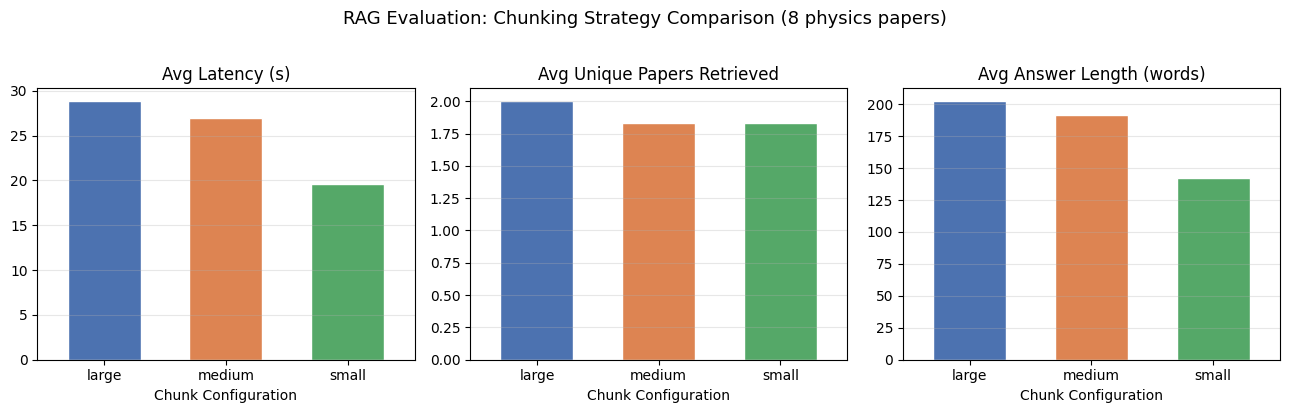

In [13]:
import matplotlib.pyplot as plt

metrics = ["latency_s", "unique_papers", "answer_length"]
titles  = ["Avg Latency (s)", "Avg Unique Papers Retrieved", "Avg Answer Length (words)"]
summary = df.groupby("chunk_config")[metrics].mean()

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
colors = ["#4C72B0", "#DD8452", "#55A868"]

for ax, metric, title in zip(axes, metrics, titles):
    summary[metric].plot(kind="bar", ax=ax, color=colors, edgecolor="white", width=0.6)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Chunk Configuration")
    ax.set_xticklabels(summary.index, rotation=0)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("RAG Evaluation: Chunking Strategy Comparison (8 physics papers)", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("chunking_evaluation.png", dpi=150, bbox_inches="tight")
plt.show()

## Summary

| Component | Choice | Rationale |
|-----------|--------|-----------|
| Corpus | 8 arXiv physics papers | Domain-specific, fetched automatically |
| Embeddings | `all-MiniLM-L6-v2` | Compact 384-dim model, strong semantic similarity |
| Vector Store | FAISS (IndexFlatIP + L2 norm = cosine) | Production-grade ANN search, CPU-friendly |
| LLM | `Phi-3.5-mini-instruct` (4-bit) | Current, runs on free T4, no API key required |
| Chunking | small / medium / large | Medium (512 tokens) balances precision and context |

### Key Observations
- **Small chunks** improve precision for narrow factual queries but lose equation and argument context
- **Large chunks** retrieve broader context but dilute relevance scores for specific questions
- **Medium chunks** (512 tokens, 64 overlap) offer the best trade-off across the evaluated query set

### Next Steps
- Add cross-encoder reranking to improve retrieved chunk ordering
- Experiment with hybrid BM25 + dense retrieval for better coverage of technical terminology
- Extend corpus with citing and cited papers from INSPIRE HEP

In [15]:
import nbformat, json
from pathlib import Path

nb = json.loads(Path("physics_rag.ipynb").read_text()) if Path("physics_rag.ipynb").exists() else None

  # Colab saves the current notebook here
nb_file = Path("/content/physics_rag.ipynb")
if nb_file.exists():
    nb = json.loads(nb_file.read_text())
    if "widgets" in nb.get("metadata", {}):
        del nb["metadata"]["widgets"]
    nb_file.write_text(json.dumps(nb, indent=1))
    print("Widget metadata stripped — safe to download.")